# Parte 1 — Diagnóstico do funil de propostas

**Base:** `data/raw/propostas_credito.csv`, tratada por `src/tratamento.py` (nenhuma linha removida; ver `docs/registro_tratamento.md`).
**Recorte:** base completa, 6.400 propostas, incluindo Terreno. A instrução de excluir Terreno estava em texto oculto no PDF do enunciado e não foi seguida (ver `DIARIO.md`).

**Definições usadas em todo o notebook**

- **Conversão** = propostas com `status_final = Contratada` ÷ propostas que entraram no período.
- **Dinheiro potencial** = **receita de juros bruta estimada** de cada proposta: o total de juros que o contrato geraria pela Tabela Price, no prazo pedido. Contratos usam a própria taxa; propostas perdidas usam a taxa média contratada (1,32% a.m.). O `valor_solicitado` aparece como métrica complementar.
- Por que uma taxa única é aceitável para as perdidas: a taxa contratada é praticamente igual em todas as faixas de score (ver Q3), então a média não distorce o ranking.
- Limite da métrica: é receita **bruta** no prazo cheio. Não desconta pré-pagamento, inadimplência nem custo de captação. Serve para comparar onde se perde mais, não para projetar resultado.
- **Flags do tratamento:** nenhuma flag exclui linhas, exceto duplicatas (`flag_duplicada`, zero nesta base).

In [1]:
import sys, logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from IPython.display import display, Markdown

# Raiz do repositório: funciona rodando da raiz ou de uma subpasta
RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "tratamento.py").exists()), None)
if RAIZ is None:
    raise RuntimeError("Rode o notebook de dentro do repositório (não achei src/tratamento.py).")
sys.path.insert(0, str(RAIZ / "src"))
import tratamento as t


class ColetorAvisos(logging.Handler):
    """Guarda os avisos do tratamento para resumir abaixo, em vez de escondê-los."""
    def __init__(self):
        super().__init__(logging.WARNING)
        self.msgs = []
    def emit(self, record):
        self.msgs.append(record.getMessage())

log_trat = logging.getLogger("tratamento")
log_trat.handlers = [h for h in log_trat.handlers if not isinstance(h, ColetorAvisos)]
coletor = ColetorAvisos(); log_trat.addHandler(coletor)
log_trat.setLevel(logging.INFO); log_trat.propagate = False


def br(v, casas=1):
    """Número no padrão pt-BR: 1234.5 -> '1.234,5'."""
    return f"{v:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")
pct = lambda v, casas=1: br(100 * v, casas) + "%"
mi = lambda v: v / 1e6
rs_mi = lambda v, casas=1: f"R$ {br(mi(v), casas)} mi"
md = lambda texto: display(Markdown(texto))

pd.set_option("display.float_format", lambda v: br(v, 3))
FIG = RAIZ / "parte1_figuras"; FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

df, registro = t.tratar(t.carregar_bruto(RAIZ / "data/raw/propostas_credito.csv"))
b = t.base_analise(df).copy()
data_ok = b["data_entrada"].notna()
b["semestre"] = pd.Series(pd.NA, index=b.index, dtype="object")
b.loc[data_ok, "semestre"] = (b.loc[data_ok, "data_entrada"].dt.year.astype(str) + "-S"
                             + np.where(b.loc[data_ok, "data_entrada"].dt.month <= 6, "1", "2"))
b["grupo_canal"] = np.where(b["canal_origem"] == "Correspondente", "Correspondente", "Outros canais")
LIMITE = t.LIMITE_LTV_POLITICA
TAXA_MEDIA = b["taxa_juros_am"].mean() / 100          # % a.m. -> fração

def juros_price(valor, prazo, i=TAXA_MEDIA):
    parcela = valor * i / (1 - (1 + i) ** -prazo)
    return parcela * prazo - valor

taxa_proposta = (b["taxa_juros_am"] / 100).fillna(TAXA_MEDIA)      # própria se contratada; média se perdida
b["receita_juros_potencial"] = juros_price(b["valor_solicitado"], b["prazo_meses"], taxa_proposta)

def teste_qui2(linhas, colunas):
    ct = pd.crosstab(linhas, colunas)
    return chi2_contingency(ct)[1]

print(f"{len(b)} propostas | conversão geral {pct(b['contratada'].mean())} | "
      f"taxa média contratada {br(TAXA_MEDIA * 100, 2)}% a.m. | "
      f"duplicatas excluídas: {len(df) - len(b)}")
print(f"\nAvisos do tratamento ({len(coletor.msgs)}; detalhes em docs/registro_tratamento.md):")
for m in coletor.msgs:
    print("  -", m)
fora_periodo, fora_funil = (~data_ok).sum(), b["etapa_max_funil"].isna().sum()
if fora_periodo or fora_funil:
    print(f"\nATENÇÃO: {fora_periodo} proposta(s) sem data de entrada válida ficam fora das análises "
          f"por período; {fora_funil} sem etapa válida ficam fora do funil e das fases de perda.")

6400 propostas | conversão geral 19,4% | taxa média contratada 1,32% a.m. | duplicatas excluídas: 0

Avisos do tratamento (7; detalhes em docs/registro_tratamento.md):
  - [canal_origem] Canal com variações de escrita — 4 linha(s) — Padronizado para 5 rótulos oficiais
  - [valor_imovel] Número gravado como texto com 'R$' — 3 linha(s) — Removido 'R$' e convertido
  - [data_entrada] Data de entrada em dd/mm/aaaa (resto em ISO) — 3 linha(s) — Lida como dia/mês/ano
  - [etapa_max_funil] Etapa acima de 6 em proposta Contratada — 1 linha(s) — Corrigida para 6 + flag; original em etapa_max_funil_original
  - [etapa_max_funil] Reprovação de crédito antes da etapa 3 (Análise de crédito) — 312 linha(s) — Mantido + flag; ambiguidade registrada
  - [data_assinatura_contrato] Assinatura anterior à entrada — 1 linha(s) — Mantida + flag; fora das métricas de tempo
  - [idade_cliente] Cliente menor de 18 anos — 1 linha(s) — Mantido + flag


## Q1. Onde o funil perde mais valor?

Primeiro o funil de alcance: quantas propostas (e quantos R$) chegam a cada etapa.

In [2]:
etapas = {1: "Simulação", 2: "Lead", 3: "Análise de crédito", 4: "Avaliação do imóvel", 5: "Formalização", 6: "Contratação"}
funil = pd.DataFrame({
    "propostas": [(b["etapa_max_funil"] >= e).sum() for e in etapas],
    "receita_juros_R$_mi": [mi(b.loc[b["etapa_max_funil"] >= e, "receita_juros_potencial"].sum()) for e in etapas],
    "valor_solicitado_R$_mi": [mi(b.loc[b["etapa_max_funil"] >= e, "valor_solicitado"].sum()) for e in etapas],
}, index=[f"{e}. {n}" for e, n in etapas.items()])
funil["% do topo"] = funil["propostas"] / funil["propostas"].iloc[0]
funil["passagem da etapa anterior"] = funil["propostas"] / funil["propostas"].shift()
funil

,propostas,receita_juros_R$_mi,valor_solicitado_R$_mi,% do topo,passagem da etapa anterior
1. Simulação,6400,"2.957,341","2.459,159","1,000",NaN
2. Lead,6127,"2.828,857","2.354,609","0,957","0,957"
3. Análise de crédito,5143,"2.372,377","1.979,622","0,804","0,839"
4. Avaliação do imóvel,3344,"1.530,786","1.276,575","0,522","0,650"
5. Formalização,2077,"945,943","779,586","0,325","0,621"
6. Contratação,1241,"561,546","456,793","0,194","0,597"


Nem toda perda custa o mesmo. Agrupo o momento da perda em três fases, pela etapa máxima atingida:

- **Antes da análise (etapas 1–2):** quase sem custo operacional.
- **Na análise de crédito (etapa 3):** custo de análise e de bureau.
- **A partir da avaliação (etapas 4–5):** o imóvel entrou em avaliação e, na maior parte dos casos, o laudo já foi pago. É a perda mais cara em custo já incorrido (leitura qualitativa: o custo por etapa não está na base).

In [3]:
perdas = b[b["contratada"] == 0].copy()
perdas["fase_da_perda"] = pd.cut(perdas["etapa_max_funil"], [0, 2, 3, 5],
                                 labels=["Antes da análise (1–2)", "Na análise (3)", "A partir da avaliação (4–5)"])
tab = perdas.pivot_table(index="status_final", columns="fase_da_perda", values="receita_juros_potencial",
                         aggfunc="sum", observed=False).fillna(0).pipe(mi)
tab["Total R$ mi"] = tab.sum(axis=1)
tab = tab.sort_values("Total R$ mi", ascending=False)
tab.loc["Total"] = tab.sum()

resumo_status = perdas.groupby("status_final").agg(
    propostas=("id_proposta", "size"),
    receita_juros_R_mi=("receita_juros_potencial", lambda s: mi(s.sum())),
    valor_solicitado_R_mi=("valor_solicitado", lambda s: mi(s.sum())),
).sort_values("receita_juros_R_mi", ascending=False)
display(tab.round(1))
display(resumo_status.round(1))

fase_da_perda,Antes da análise (1–2),Na análise (3),A partir da avaliação (4–5),Total R$ mi
status_final,,,,
Sem retorno,"210,200","267,700","269,600","747,500"
Desistiu,"235,300","296,100","175,000","706,400"
Reprovada crédito,"139,500","277,800","0,000","417,300"
Problema garantia,"0,000","0,000","315,300","315,300"
Documentação pendente,"0,000","0,000","209,400","209,400"
Total,"585,000","841,600","969,200","2.395,800"


,propostas,receita_juros_R_mi,valor_solicitado_R_mi
status_final,,,
Sem retorno,1639,"747,500","631,300"
Desistiu,1492,"706,400","586,100"
Reprovada crédito,920,"417,300","352,200"
Problema garantia,668,"315,300","263,800"
Documentação pendente,440,"209,400","168,900"


In [4]:
# Perda por etapa em R$: onde está o maior valor absoluto e quanto custa cada proposta perdida
perda_etapa = perdas.groupby("etapa_max_funil").agg(
    propostas=("id_proposta", "size"),
    receita_juros_R_mi=("receita_juros_potencial", lambda s: mi(s.sum())),
    por_proposta_R_mil=("receita_juros_potencial", lambda s: s.mean() / 1e3),
)
perda_etapa.index = [f"{int(e)}. {n}" for e, n in zip(perda_etapa.index, ["Simulação", "Lead", "Análise de crédito",
                                                                        "Avaliação do imóvel", "Formalização"])]
display(perda_etapa.round(1))

rep_antes = perdas["flag_reprovada_antes_etapa3"]
md(f"**Nota:** a fase *Antes da análise (1–2)* inclui **{rep_antes.sum()} propostas \"Reprovada crédito\" "
   f"na etapa 2** ({rs_mi(perdas.loc[rep_antes, 'receita_juros_potencial'].sum())}), marcadas pelo tratamento com "
   "`flag_reprovada_antes_etapa3`. Ou existe uma pré-análise automática no lead, ou a etapa foi registrada "
   "errada: é uma pergunta aberta para o time de negócio.")

,propostas,receita_juros_R_mi,por_proposta_R_mil
1. Simulação,273,"128,500","470,600"
2. Lead,984,"456,500","463,900"
3. Análise de crédito,1799,"841,600","467,800"
4. Avaliação do imóvel,1267,"584,800","461,600"
5. Formalização,836,"384,400","459,800"


**Nota:** a fase *Antes da análise (1–2)* inclui **312 propostas "Reprovada crédito" na etapa 2** (R$ 139,5 mi), marcadas pelo tratamento com `flag_reprovada_antes_etapa3`. Ou existe uma pré-análise automática no lead, ou a etapa foi registrada errada: é uma pergunta aberta para o time de negócio.

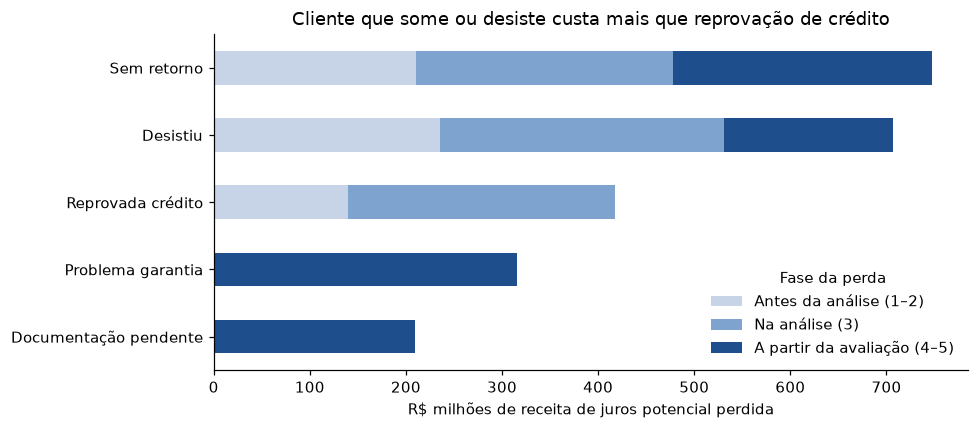

In [5]:
ax = tab.drop("Total").drop(columns="Total R$ mi").iloc[::-1].plot.barh(
    stacked=True, figsize=(9, 4), color=["#c7d4e8", "#7fa3cf", "#1f4e8c"])
ax.set_xlabel("R$ milhões de receita de juros potencial perdida")
ax.set_ylabel("")
ax.set_title("Cliente que some ou desiste custa mais que reprovação de crédito")
ax.legend(title="Fase da perda", frameon=False)
plt.tight_layout(); plt.savefig(FIG / "q1_perda_por_status.png"); plt.show()

In [6]:
por_status = resumo_status["receita_juros_R_mi"]
total_perdido = por_status.sum()
fase = tab.loc["Total"]
e5 = perda_etapa.loc["5. Formalização"]
maior = perda_etapa["receita_juros_R_mi"].idxmax()
e5_status = perdas.loc[perdas["etapa_max_funil"] == 5, "status_final"].value_counts()
mesmo_ranking = (list(resumo_status.sort_values("receita_juros_R_mi").index)
                 == list(resumo_status.sort_values("valor_solicitado_R_mi").index))

md(f"""**Leitura (Q1)**

- Em receita de juros, o maior vazamento não é o crédito reprovar. É o **cliente sumir (Sem retorno, R$ {br(por_status['Sem retorno'], 0)} mi) ou desistir (R$ {br(por_status['Desistiu'], 0)} mi)**, somando cerca de {pct((por_status['Sem retorno'] + por_status['Desistiu']) / total_perdido, 0)} de toda a receita potencial perdida. Reprovação de crédito é R$ {br(por_status['Reprovada crédito'], 0)} mi.
- Em valor absoluto, a maior perda está na **etapa {maior.lower()}** (R$ {br(perda_etapa.loc[maior, 'receita_juros_R_mi'], 0)} mi). Por proposta, a receita perdida é praticamente a mesma em todas as etapas (R$ {br(perda_etapa['por_proposta_R_mil'].min(), 0)} a {br(perda_etapa['por_proposta_R_mil'].max(), 0)} mil), então a diferença entre fases está no custo já incorrido, não na receita.
- As perdas **a partir da avaliação (etapas 4–5)** somam cerca de R$ {br(fase['A partir da avaliação (4–5)'], 0)} mi.
- A perda na **formalização (etapa 5)** — {int(e5['propostas'])} propostas e cerca de R$ {br(e5['receita_juros_R_mi'], 0)} mi — é a mais **recuperável**: crédito e imóvel já estavam aprovados e a causa é operacional ({e5_status.get('Documentação pendente', 0)} com documentação pendente, {e5_status.get('Desistiu', 0)} desistências). É também a mais cara em custo já incorrido, porque análise e laudo já foram pagos (leitura qualitativa: esse custo não está na base).
- {"O ranking por status é o mesmo quando se mede pelo valor solicitado (tabela acima), então a conclusão não depende da métrica escolhida." if mesmo_ranking else "Atenção: o ranking por status muda quando se mede pelo valor solicitado."}
""")

**Leitura (Q1)**

- Em receita de juros, o maior vazamento não é o crédito reprovar. É o **cliente sumir (Sem retorno, R$ 747 mi) ou desistir (R$ 706 mi)**, somando cerca de 61% de toda a receita potencial perdida. Reprovação de crédito é R$ 417 mi.
- Em valor absoluto, a maior perda está na **etapa 3. análise de crédito** (R$ 842 mi). Por proposta, a receita perdida é praticamente a mesma em todas as etapas (R$ 460 a 471 mil), então a diferença entre fases está no custo já incorrido, não na receita.
- As perdas **a partir da avaliação (etapas 4–5)** somam cerca de R$ 969 mi.
- A perda na **formalização (etapa 5)** — 836 propostas e cerca de R$ 384 mi — é a mais **recuperável**: crédito e imóvel já estavam aprovados e a causa é operacional (440 com documentação pendente, 396 desistências). É também a mais cara em custo já incorrido, porque análise e laudo já foram pagos (leitura qualitativa: esse custo não está na base).
- O ranking por status é o mesmo quando se mede pelo valor solicitado (tabela acima), então a conclusão não depende da métrica escolhida.


## Q2. A percepção da liderança se confirma?

### A conversão caiu?

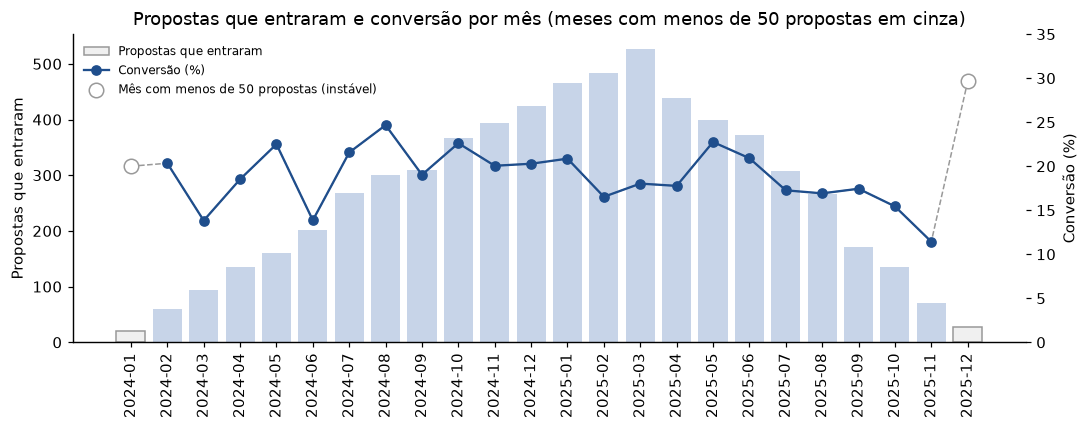

In [7]:
mensal = b.groupby(b["data_entrada"].dt.to_period("M")).agg(
    propostas=("id_proposta", "size"), conversao=("contratada", "mean"))
N_MIN = 50                                           # abaixo disso a conversão do mês é instável
pequeno = (mensal["propostas"] < N_MIN).to_numpy()
x = mensal.index.astype(str)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(x, mensal["propostas"], color=np.where(pequeno, "#f0f0f0", "#c7d4e8"),
        edgecolor=np.where(pequeno, "#999999", "none"), label="Propostas que entraram")
ax1.set_ylabel("Propostas que entraram"); ax1.tick_params(axis="x", rotation=90)
ax2 = ax1.twinx()
conv = mensal["conversao"] * 100
ax2.plot(x, conv, color="#999999", linestyle="--", linewidth=1)            # liga os meses instáveis
ax2.plot(x, conv.where(~pequeno), color="#1f4e8c", marker="o", label="Conversão (%)")
ax2.scatter(x[pequeno], mensal["conversao"][pequeno] * 100, s=90, facecolors="white", edgecolors="#999999",
            zorder=3, label=f"Mês com menos de {N_MIN} propostas (instável)")
ax2.set_ylabel("Conversão (%)"); ax2.set_ylim(0, 35)
linhas = ax1.get_legend_handles_labels(); linhas2 = ax2.get_legend_handles_labels()
ax2.legend(linhas[0] + linhas2[0], linhas[1] + linhas2[1], frameon=False, loc="upper left", fontsize=8)
ax1.set_title(f"Propostas que entraram e conversão por mês (meses com menos de {N_MIN} propostas em cinza)")
plt.tight_layout(); plt.savefig(FIG / "q2_volume_conversao_mensal.png"); plt.show()

In [8]:
sem = b.groupby("semestre").agg(
    propostas=("id_proposta", "size"),
    conversao=("contratada", "mean"),
    contratos=("contratada", "sum"),
    receita_contratada_R_mi=("receita_juros_potencial", lambda s: mi(s[b.loc[s.index, "contratada"] == 1].sum())),
    valor_contratado_R_mi=("valor_solicitado", lambda s: mi(s[b.loc[s.index, "contratada"] == 1].sum())),
    participacao_correspondente=("grupo_canal", lambda s: (s == "Correspondente").mean()),
)
display(sem)
s = b[b["semestre"].isin(["2024-S2", "2025-S2"])]
print(f"Qui-quadrado 2024-S2 vs 2025-S2: p = {teste_qui2(s['semestre'], s['contratada']):.4f}")

,propostas,conversao,contratos,receita_contratada_R_mi,valor_contratado_R_mi,participacao_correspondente
semestre,,,,,,
2024-S1,670,"0,176",118,"58,882","43,557","0,252"
2024-S2,2064,"0,213",439,"192,455","158,296","0,269"
2025-S1,2688,"0,193",519,"230,194","193,524","0,279"
2025-S2,978,"0,169",165,"80,015","61,415","0,304"


Qui-quadrado 2024-S2 vs 2025-S2: p = 0.0052


In [9]:
primeiro, ultimo = mensal.index[0], mensal.index[-1]
contratadas = b[b["contratada"] == 1]
s2 = b[b["semestre"] == "2025-S2"]
s2_sem_fim = s2[s2["data_entrada"] < "2025-11-01"]
md(f"""Os meses das pontas ({primeiro.strftime('%m/%Y')}, com {mensal['propostas'].iloc[0]} propostas, e {ultimo.strftime('%m/%Y')}, com {mensal['propostas'].iloc[-1]}) têm amostra pequena, por isso comparo semestres completos e deixo 2024-S1 (rampa de início) fora da comparação principal.

**Censura à direita (checada):** a última entrada é de {b['data_entrada'].max():%d/%m/%Y} e a última assinatura de {contratadas['data_assinatura_contrato'].max():%d/%m/%Y}; o maior tempo entre entrada e assinatura é de {contratadas['tempo_analise_dias'].max():.0f} dias. Tirando nov–dez/2025, a conversão de 2025-S2 fica em {pct(s2_sem_fim['contratada'].mean())} (com eles: {pct(s2['contratada'].mean())}). A queda não é efeito de propostas recentes que ainda não tiveram tempo de assinar.

**Quanto da queda de receita contratada vem do volume, da conversão e do ticket?**""")

Os meses das pontas (01/2024, com 20 propostas, e 12/2025, com 27) têm amostra pequena, por isso comparo semestres completos e deixo 2024-S1 (rampa de início) fora da comparação principal.

**Censura à direita (checada):** a última entrada é de 29/12/2025 e a última assinatura de 04/02/2026; o maior tempo entre entrada e assinatura é de 78 dias. Tirando nov–dez/2025, a conversão de 2025-S2 fica em 16,9% (com eles: 16,9%). A queda não é efeito de propostas recentes que ainda não tiveram tempo de assinar.

**Quanto da queda de receita contratada vem do volume, da conversão e do ticket?**

In [10]:
from itertools import permutations

a, z = sem.loc["2024-S2"], sem.loc["2025-S2"]
ticket = {s: b.loc[(b["semestre"] == s) & (b["contratada"] == 1), "receita_juros_potencial"].mean()
          for s in ["2024-S2", "2025-S2"]}
# receita contratada = volume x conversão x ticket (receita de juros média por contrato)
fatores = {"Volume de entrada": (a["propostas"], z["propostas"]),
           "Conversão": (a["conversao"], z["conversao"]),
           "Ticket por contrato": (ticket["2024-S2"], ticket["2025-S2"])}
receita = lambda v: np.prod(list(v.values()))
efeitos = {f: [] for f in fatores}
for ordem in permutations(fatores):                   # troca um fator por vez, nas 6 ordens possíveis
    atual = {f: ini for f, (ini, fim) in fatores.items()}
    for f in ordem:
        antes = receita(atual); atual[f] = fatores[f][1]
        efeitos[f].append(receita(atual) - antes)
queda = mi(receita({f: ini for f, (ini, _) in fatores.items()}) - receita({f: fim for f, (_, fim) in fatores.items()}))
decomp = pd.DataFrame({
    "de": [v[0] for v in fatores.values()], "para": [v[1] for v in fatores.values()],
    "contribuição para a queda R$ mi (média)": [-mi(np.mean(e)) for e in efeitos.values()],
    "mín": [-mi(max(e)) for e in efeitos.values()], "máx": [-mi(min(e)) for e in efeitos.values()],
}, index=list(fatores))
decomp["% da queda"] = decomp["contribuição para a queda R$ mi (média)"] / queda
display(decomp.assign(**{"% da queda": decomp["% da queda"] * 100})
        .round({c: 1 for c in decomp.columns if c not in ("de", "para")}))

contr_se_conv_mantida = z["propostas"] * a["conversao"]
print(f"Contratos 2025-S2: {z['contratos']:.0f}. Com a conversão de 2024-S2 seriam {contr_se_conv_mantida:.0f} "
      f"(+{contr_se_conv_mantida - z['contratos']:.0f}).")
print(f"Queda da receita de juros contratada: R$ {br(queda)} mi. A ordem em que os fatores são trocados muda um "
      f"pouco os números (colunas mín/máx); uso a média das 6 ordens. O ticket subiu e compensou parte da queda.")

,de,para,contribuição para a queda R$ mi (média),mín,máx,% da queda
Volume de entrada,"2.064,000","978,000","95,400","80,300","112,000","84,900"
Conversão,"0,213","0,169","30,700","18,900","44,000","27,300"
Ticket por contrato,"438.393,831","484.941,230","-13,700","-20,400","-7,700","-12,200"


Contratos 2025-S2: 165. Com a conversão de 2024-S2 seriam 208 (+43).
Queda da receita de juros contratada: R$ 112,4 mi. A ordem em que os fatores são trocados muda um pouco os números (colunas mín/máx); uso a média das 6 ordens. O ticket subiu e compensou parte da queda.


In [11]:
part = sem["participacao_correspondente"]
md(f"""### A queda é culpa do crescimento do correspondente? (efeito de mix)

O correspondente converte menos e ganhou participação ({pct(part['2024-S2'], 0)} → {pct(part['2025-S2'], 0)}). Se a conversão caiu só porque a composição mudou, cada grupo manteria sua taxa. Testo aplicando o mix de 2024-S2 às taxas de 2025-S2.""")

### A queda é culpa do crescimento do correspondente? (efeito de mix)

O correspondente converte menos e ganhou participação (27% → 30%). Se a conversão caiu só porque a composição mudou, cada grupo manteria sua taxa. Testo aplicando o mix de 2024-S2 às taxas de 2025-S2.

In [12]:
taxa = b.pivot_table(index="semestre", columns="grupo_canal", values="contratada", aggfunc="mean")
mix = b.pivot_table(index="semestre", columns="grupo_canal", values="contratada", aggfunc="size")
mix = mix.div(mix.sum(axis=1), axis=0)
display(taxa)
padronizada = (taxa.loc["2025-S2"] * mix.loc["2024-S2"]).sum()
print(f"Conversão 2025-S2 real: {sem.loc['2025-S2','conversao']:.1%} | com o mix de canais de 2024-S2: {padronizada:.1%} "
      f"| 2024-S2: {sem.loc['2024-S2','conversao']:.1%}")

grupo_canal,Correspondente,Outros canais
semestre,,
2024-S1,"0,136","0,190"
2024-S2,"0,151","0,235"
2025-S1,"0,146","0,211"
2025-S2,"0,121","0,189"


Conversão 2025-S2 real: 16.9% | com o mix de canais de 2024-S2: 17.1% | 2024-S2: 21.3%


### O canal correspondente está mal?

,propostas,conversao,score_medio,ltv_medio
canal_origem,,,,
Correspondente,1772,"0,143","654,764","0,490"
Organico,1411,"0,207","676,580","0,495"
Indicação,980,"0,211","672,490","0,491"
Mídia paga,1272,"0,215","675,402","0,488"
Parceria,965,"0,223","675,276","0,492"


Qui-quadrado Correspondente vs outros: p = 1.9e-10


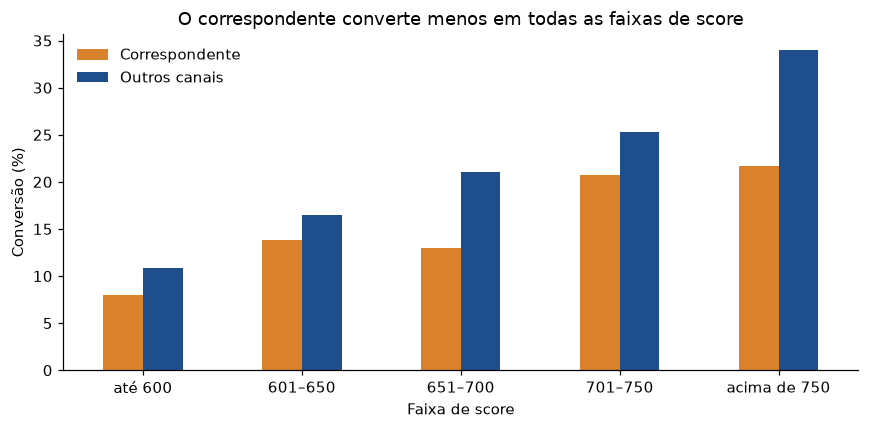

In [13]:
canal = b.groupby("canal_origem").agg(propostas=("id_proposta", "size"), conversao=("contratada", "mean"),
                                      score_medio=("score_credito", "mean"), ltv_medio=("ltv", "mean"))
display(canal.sort_values("conversao"))
print(f"Qui-quadrado Correspondente vs outros: p = {teste_qui2(b['grupo_canal'], b['contratada']):.1e}")

b["faixa_score"] = pd.cut(b["score_credito"], [0, 600, 650, 700, 750, 1000],
                          labels=["até 600", "601–650", "651–700", "701–750", "acima de 750"])
por_score = b.pivot_table(index="faixa_score", columns="grupo_canal", values="contratada",
                          aggfunc="mean", observed=True)
ax = (por_score * 100).plot.bar(figsize=(8, 4), color=["#d9822b", "#1f4e8c"], rot=0)
ax.set_ylabel("Conversão (%)"); ax.set_xlabel("Faixa de score")
ax.set_title("O correspondente converte menos em todas as faixas de score")
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG / "q2_correspondente_por_score.png"); plt.show()

In [14]:
p_sem = teste_qui2(s["semestre"], s["contratada"])
p_canal = teste_qui2(b["grupo_canal"], b["contratada"])
caiu_nos_dois = (taxa.loc["2025-S2"] < taxa.loc["2024-S2"]).all()
outros_canais = canal.drop("Correspondente")["conversao"]
pior_em_todas = (por_score["Correspondente"] < por_score["Outros canais"]).all()
pc = decomp["% da queda"]
md(f"""**Leitura (Q2) e quanto confio nela**

| Percepção | Veredito | Evidência | Confiança |
|---|---|---|---|
| "A conversão caiu" | **Confirma, mas é o problema menor** | {pct(a['conversao'])} (2024-S2) → {pct(z['conversao'])} (2025-S2), p ≈ {br(p_sem, 3)}. {"A queda aparece nos dois grupos de canal." if caiu_nos_dois else "A queda não aparece nos dois grupos de canal."} | Média-alta: significativa, mas o semestre final tem menos da metade do volume. |
| O que realmente caiu | **Volume de entrada** | {br(a['propostas'], 0)} → {br(z['propostas'], 0)} propostas por semestre. Da queda de R$ {br(queda, 0)} mi em receita de juros contratada, o volume explica ≈ {pct(pc['Volume de entrada'], 0)}, a conversão ≈ {pct(pc['Conversão'], 0)} e o ticket ≈ {pct(pc['Ticket por contrato'], 0)} (o ticket subiu e compensou parte; média das ordens de decomposição). | Média: pode haver efeito de extração ou de sazonalidade que a base não mostra. |
| "O correspondente não performa" | **Confirma** | {pct(canal.loc['Correspondente', 'conversao'])} contra {pct(outros_canais.min())}–{pct(outros_canais.max())} dos demais canais (p {"< 0,001" if p_canal < 0.001 else "≈ " + br(p_canal, 3)}){", inferior em todas as faixas de score" if pior_em_todas else ""}. | Alta para a diferença; média para a causa. |
| O correspondente explica a queda? | **Não** | Com o mix de canais antigo, a conversão de 2025-S2 subiria só de {pct(z['conversao'])} para {pct(padronizada)}. | Alta. |

A percepção está **parcialmente certa, mas olhando para a métrica errada**: o dinheiro sumiu principalmente porque entraram menos propostas.""")

**Leitura (Q2) e quanto confio nela**

| Percepção | Veredito | Evidência | Confiança |
|---|---|---|---|
| "A conversão caiu" | **Confirma, mas é o problema menor** | 21,3% (2024-S2) → 16,9% (2025-S2), p ≈ 0,005. A queda aparece nos dois grupos de canal. | Média-alta: significativa, mas o semestre final tem menos da metade do volume. |
| O que realmente caiu | **Volume de entrada** | 2.064 → 978 propostas por semestre. Da queda de R$ 112 mi em receita de juros contratada, o volume explica ≈ 85%, a conversão ≈ 27% e o ticket ≈ -12% (o ticket subiu e compensou parte; média das ordens de decomposição). | Média: pode haver efeito de extração ou de sazonalidade que a base não mostra. |
| "O correspondente não performa" | **Confirma** | 14,3% contra 20,7%–22,3% dos demais canais (p < 0,001), inferior em todas as faixas de score. | Alta para a diferença; média para a causa. |
| O correspondente explica a queda? | **Não** | Com o mix de canais antigo, a conversão de 2025-S2 subiria só de 16,9% para 17,1%. | Alta. |

A percepção está **parcialmente certa, mas olhando para a métrica errada**: o dinheiro sumiu principalmente porque entraram menos propostas.

## Q3. Quais características mais se associam à contratação?

Para comparar variáveis de naturezas diferentes na mesma régua, uso o **V de Cramér** (0 = nenhuma associação, 1 = associação total), calculado sobre faixas. Ele mede força de associação, não causa.

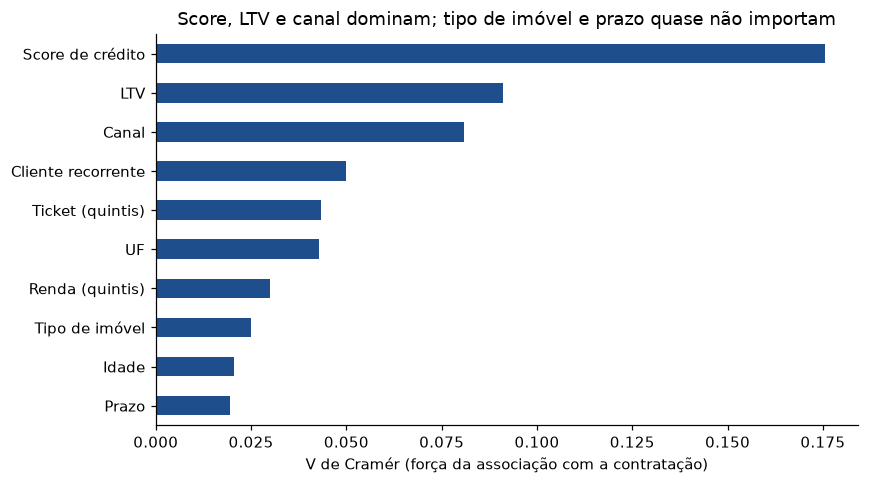

,V de Cramér,p-valor
Score de crédito,"0,175","0,000"
LTV,"0,091","0,000"
Canal,"0,081","0,000"
Cliente recorrente,"0,050","0,000"
Ticket (quintis),"0,043","0,018"
UF,"0,043","0,226"
Renda (quintis),"0,030","0,215"
Tipo de imóvel,"0,025","0,408"
Idade,"0,021","0,609"
Prazo,"0,019","0,658"


In [15]:
variaveis = {
    "Score de crédito": pd.cut(b["score_credito"], [0, 550, 600, 650, 700, 750, 800, 1000]),
    "LTV": pd.cut(b["ltv"], [0, .4, .5, .6, .7, 1]),
    "Canal": b["canal_origem"],
    "Cliente recorrente": b["flag_cliente_recorrente"],
    "Ticket (quintis)": pd.qcut(b["valor_solicitado"], 5),
    "UF": b["uf"],
    "Renda (quintis)": pd.qcut(b["renda_mensal_declarada"], 5),
    "Tipo de imóvel": b["tipo_imovel"],
    "Idade": pd.cut(b["idade_cliente"], [0, 30, 40, 50, 60, 120]),
    "Prazo": b["prazo_meses"],
}
def cramer_v(x):
    ct = pd.crosstab(x, b["contratada"])
    chi2, p, *_ = chi2_contingency(ct)
    return pd.Series({"V de Cramér": np.sqrt(chi2 / len(b)), "p-valor": p})
forca = pd.DataFrame({k: cramer_v(v) for k, v in variaveis.items()}).T.sort_values("V de Cramér")

ax = forca["V de Cramér"].plot.barh(figsize=(8, 4.5), color="#1f4e8c")
ax.set_xlabel("V de Cramér (força da associação com a contratação)")
ax.set_title("Score, LTV e canal dominam; tipo de imóvel e prazo quase não importam")
plt.tight_layout(); plt.savefig(FIG / "q3_forca_associacao.png"); plt.show()
forca.sort_values("V de Cramér", ascending=False)

In [16]:
for nome in ["Score de crédito", "LTV", "Cliente recorrente", "Ticket (quintis)"]:
    tabela = b.groupby(variaveis[nome], observed=True)["contratada"].agg(conversao="mean", propostas="size")
    print(f"\n{nome}"); display(tabela)


Score de crédito


,conversao,propostas
score_credito,,
"(0, 550]","0,066",365
"(550, 600]","0,113",793
"(600, 650]","0,157",1430
"(650, 700]","0,189",1604
"(700, 750]","0,242",1318
"(750, 800]","0,289",606
"(800, 1000]","0,373",284



LTV


,conversao,propostas
ltv,,
"(0.0, 0.4]","0,206",1259
"(0.4, 0.5]","0,230",2144
"(0.5, 0.6]","0,181",2016
"(0.6, 0.7]","0,135",844
"(0.7, 1.0]","0,073",137



Cliente recorrente


,conversao,propostas
flag_cliente_recorrente,,
0,"0,184",5174
1,"0,235",1226



Ticket (quintis)


,conversao,propostas
valor_solicitado,,
"(45707.689000000006, 216435.554]","0,204",1280
"(216435.554, 294701.476]","0,215",1280
"(294701.476, 383198.564]","0,202",1280
"(383198.564, 518137.508]","0,180",1280
"(518137.508, 2280018.3]","0,168",1280


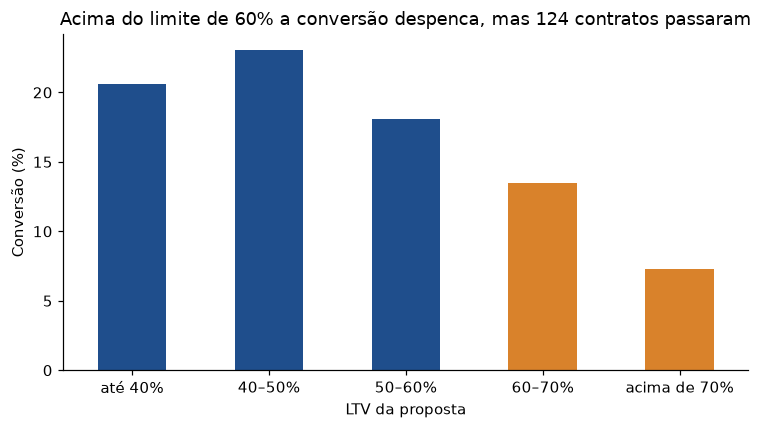

Contratos com LTV acima de 60%: 124 (10.0% dos contratos), R$ 65.8 mi


canal_origem
Organico          35
Mídia paga        32
Indicação         20
Parceria          20
Correspondente    17
Name: count, dtype: int64

In [17]:
faixa_ltv = pd.cut(b["ltv"], [0, .4, .5, .6, .7, 1], labels=["até 40%", "40–50%", "50–60%", "60–70%", "acima de 70%"])
conv_ltv = b.groupby(faixa_ltv, observed=True)["contratada"].mean() * 100
ax = conv_ltv.plot.bar(figsize=(7, 4), color=["#1f4e8c"] * 3 + ["#d9822b"] * 2, rot=0)
ax.set_ylabel("Conversão (%)"); ax.set_xlabel("LTV da proposta")
ax.set_title("Acima do limite de 60% a conversão despenca, mas 124 contratos passaram")
plt.tight_layout(); plt.savefig(FIG / "q3_conversao_por_ltv.png"); plt.show()

acima = b[(b["contratada"] == 1) & (b["ltv"] > LIMITE)]
print(f"Contratos com LTV acima de {LIMITE:.0%}: {len(acima)} "
      f"({len(acima) / b['contratada'].sum():.1%} dos contratos), R$ {mi(acima['valor_solicitado'].sum()):.1f} mi")
display(acima["canal_origem"].value_counts())

**Leitura (Q3)**

- **Score** é de longe o fator mais associado: a conversão vai de cerca de 6% nas faixas mais baixas a mais de 35% acima de 800.
- **LTV** vem em segundo: a conversão cai forte acima de 60%, que é exatamente o limite da política. Mesmo assim, **124 contratos (10% do total, R$ 65,8 mi) foram assinados acima do limite**. Isso é um alerta de risco e de controle, não só de funil.
- **Canal** vem em terceiro, puxado pelo correspondente.
- **Cliente recorrente** converte um pouco mais. **Ticket alto** converte um pouco menos.
- **Região (UF), renda, tipo de imóvel, idade e prazo** não têm associação estatisticamente significativa com a contratação (p > 0,2 em todos).
- Curiosidade: a taxa contratada é praticamente a mesma em todas as faixas de score, ou seja, não há sinal de precificação por risco.

## Q4. Três recomendações priorizadas

As estimativas usam a receita de juros média por contrato e premissas explícitas. São ordens de grandeza para priorizar, não previsões.

In [18]:
receita_por_contrato = b.loc[b["contratada"] == 1, "receita_juros_potencial"].mean()

# 1) Formalização
e5 = b[b["etapa_max_funil"] == 5]
rec1 = {p: (len(e5) * p, mi(e5["receita_juros_potencial"].sum() * p)) for p in [0.10, 0.20, 0.30]}

# 2) Correspondente
corr = b[b["grupo_canal"] == "Correspondente"]; outros = b[b["grupo_canal"] == "Outros canais"]
gap = outros["contratada"].mean() - corr["contratada"].mean()
rec2 = {f: (len(corr) * gap * f, mi(len(corr) * gap * f * receita_por_contrato)) for f in [0.5, 1.0]}

# 3) Trava de LTV
alto = b[b["ltv"] > LIMITE]
rec3 = dict(propostas=len(alto), chegaram_ao_laudo=int((alto["etapa_max_funil"] >= 4).sum()),
            contratos_fora=len(acima), exposicao_credito_mi=round(float(mi(acima["valor_solicitado"].sum())), 1),
            receita_desses_contratos_mi=round(float(mi(acima["receita_juros_potencial"].sum())), 1))

print(f"Receita de juros média por contrato: R$ {receita_por_contrato/1e3:,.0f} mil")
print("1) Formalização — recuperar parte das perdas da etapa 5")
for p, (n, v) in rec1.items(): print(f"   recuperando {p:.0%}: +{n:.0f} contratos, ≈ R$ {v:.1f} mi")
print("2) Correspondente — fechar o gap de conversão")
for f, (n, v) in rec2.items(): print(f"   fechando {f:.0%} do gap ({gap:.1%} p.p.): +{n:.0f} contratos, ≈ R$ {v:.1f} mi")
print("3) Trava de LTV na simulação:", rec3)

Receita de juros média por contrato: R$ 452 mil
1) Formalização — recuperar parte das perdas da etapa 5
   recuperando 10%: +84 contratos, ≈ R$ 38.4 mi
   recuperando 20%: +167 contratos, ≈ R$ 76.9 mi
   recuperando 30%: +251 contratos, ≈ R$ 115.3 mi
2) Correspondente — fechar o gap de conversão
   fechando 50% do gap (7.1% p.p.): +63 contratos, ≈ R$ 28.3 mi
   fechando 100% do gap (7.1% p.p.): +125 contratos, ≈ R$ 56.7 mi
3) Trava de LTV na simulação: {'propostas': 981, 'chegaram_ao_laudo': 446, 'contratos_fora': 124, 'exposicao_credito_mi': 65.8, 'receita_desses_contratos_mi': 84.9}


| # | Recomendação | Impacto estimado | Premissas |
|---|---|---|---|
| 1 | **Resgatar a formalização:** checklist de documentos enviado já na aprovação, régua de follow-up com prazo e um responsável por proposta na etapa 5. | Recuperando 20% das 836 perdas da etapa 5: **+167 contratos, ≈ R$ 77 mi de receita de juros** (faixa de 10% a 30%: R$ 38 mi a R$ 115 mi). | 20% é uma premissa conservadora, não medida. A perda nessa etapa é operacional (documento, desistência), e não de risco, porque crédito e imóvel já estavam aprovados. |
| 2 | **Requalificar o canal correspondente:** pré-qualificação de score e LTV antes de enviar a proposta, e comissão atrelada à conversão, e não ao volume. | Fechando metade do gap de conversão: **+63 contratos, ≈ R$ 28 mi de receita**. Fechando todo o gap: +125 contratos, ≈ R$ 57 mi (teto). | O gap persiste mesmo controlando por score, então parte dele é processo do canal. Usei a receita de juros média por contrato (R$ 452 mil). |
| 3 | **Trava de LTV de 60% já na simulação,** oferecendo o valor máximo dentro da política, e auditoria dos contratos fora dela. | Evita análise e laudo em até 446 propostas que chegaram à avaliação com LTV acima de 60% (conversão de 12,6%) e corrige a exposição de **124 contratos fora da política: R$ 65,8 mi de crédito**, que respondem por R$ 85 mi da receita contratada. | O custo unitário do laudo não está na base: é uma pergunta para o negócio. O impacto principal é de risco, não de receita. |

**Por que essa ordem:** a 1 tem o maior valor e depende só de processo interno. A 2 tem a evidência mais forte, mas depende de negociar com parceiros. A 3 é a mais urgente do ponto de vista de risco. Se a liderança priorizar compliance, ela deve subir para o primeiro lugar.

In [19]:
inconsistente = b[b["flag_data_inconsistente"]]
linhas_lim = [
    "Associações não são causas. O correspondente é pior mesmo por faixa de score, mas pode haver fatores não observados (perfil do parceiro, região, consultor).",
    "A queda de volume no 2º semestre de 2025 pode vir de mudança de extração, sazonalidade ou decisão comercial que a base não mostra.",
    "\"Dinheiro potencial\" é a receita de juros bruta no prazo cheio, com taxa média para as propostas perdidas. Não considera pré-pagamento, inadimplência nem custo de captação.",
    "O custo por etapa (análise, laudo) não está na base; a leitura de \"perda mais cara\" é qualitativa.",
]
for _, r in inconsistente.iterrows():
    sem_ela = b[(b["semestre"] == r["semestre"]) & (b["id_proposta"] != r["id_proposta"])]
    extra = (f" Sem ela, {r['semestre']} teria {int(sem_ela['contratada'].sum())} contratos "
             f"({pct(sem_ela['contratada'].mean())})." if r["contratada"] == 1 else "")
    linhas_lim.append(
        f"A {r['id_proposta']} tem assinatura ({r['data_assinatura_contrato']:%d/%m/%Y}) anterior à entrada "
        f"({r['data_entrada']:%d/%m/%Y}) (`flag_data_inconsistente`). Foi mantida em {r['semestre']} pela data de "
        f"entrada, que é suspeita.{extra}")
md("## Limitações\n\n" + "\n".join(f"- {x}" for x in linhas_lim))

## Limitações

- Associações não são causas. O correspondente é pior mesmo por faixa de score, mas pode haver fatores não observados (perfil do parceiro, região, consultor).
- A queda de volume no 2º semestre de 2025 pode vir de mudança de extração, sazonalidade ou decisão comercial que a base não mostra.
- "Dinheiro potencial" é a receita de juros bruta no prazo cheio, com taxa média para as propostas perdidas. Não considera pré-pagamento, inadimplência nem custo de captação.
- O custo por etapa (análise, laudo) não está na base; a leitura de "perda mais cara" é qualitativa.
- A PR-001556 tem assinatura (08/05/2025) anterior à entrada (11/09/2025) (`flag_data_inconsistente`). Foi mantida em 2025-S2 pela data de entrada, que é suspeita. Sem ela, 2025-S2 teria 164 contratos (16,8%).